In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm


In [2]:
cd ../../

/Users/ann/Documents/Quant finance study/WSQ/quant_project


In [3]:
from src.get_data.read_data import get_rets
from src.analysis.plotting import plot_corr
from src.pca.pca import calc_resid_pca, plot_explained_variance, plot_loadings
from src.signal_construction.transform_signal import transform_signal, dollar_neutral_weights

from src.signal_construction.reduce_trading import partial_adjustment_weights

import src.analysis.stats as stats

In [4]:
start_ts = '2022-01-01'
end_ts = '2025-12-31'

In [5]:
parquet_path = f"src/data/rets_full_{start_ts[:4]}_to_{end_ts[:4]}.parquet"

In [6]:
if os.path.exists(parquet_path):
    rets = pd.read_parquet(parquet_path)
else:
    rets, px = get_rets(freq='4h',start_ts = start_ts,end_ts=end_ts)
    rets.to_parquet(parquet_path)

In [7]:
rets.columns

Index(['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'MATICUSDT',
       'ADAUSDT', 'DOGEUSDT', 'TRXUSDT', 'AVAXUSDT', 'DOTUSDT', 'LTCUSDT',
       'LINKUSDT', 'NEARUSDT', 'ATOMUSDT', 'ALGOUSDT', 'XLMUSDT', 'SANDUSDT',
       'APEUSDT', 'FILUSDT', 'AAVEUSDT', 'EOSUSDT', 'ICPUSDT', 'THETAUSDT',
       'MANAUSDT', 'VETUSDT', 'EGLDUSDT', 'FLOWUSDT', 'HBARUSDT', 'FTMUSDT',
       'QNTUSDT', 'RAYUSDT', 'KLAYUSDT', 'GRTUSDT', 'STXUSDT', 'XMRUSDT',
       'ZECUSDT', 'CHZUSDT', 'XTZUSDT', 'CRVUSDT', 'BATUSDT', 'ENJUSDT',
       'MKRUSDT', 'COMPUSDT', 'DYDXUSDT', 'ONEUSDT', 'CELOUSDT', 'ARBUSDT',
       'SUIUSDT', 'SUSHIUSDT', 'SNXUSDT', 'RUNEUSDT', 'KSMUSDT', 'ZILUSDT',
       'ICXUSDT', 'RENUSDT', 'KAVAUSDT', 'ONTUSDT', 'IOTAUSDT', 'QTUMUSDT',
       'OMGUSDT', 'ANKRUSDT', 'STORJUSDT', '1INCHUSDT', 'SRMUSDT', 'SKLUSDT',
       'COTIUSDT', 'DGBUSDT', 'BANDUSDT', 'OCEANUSDT', 'ARPAUSDT', 'LRCUSDT'],
      dtype='object')

In [8]:
daily_rets = rets.iloc[115:,]   #rets.iloc[5::6,]
daily_rets = daily_rets.loc[:"20241231"]
#daily_rets = daily_rets.dropna(axis=1)

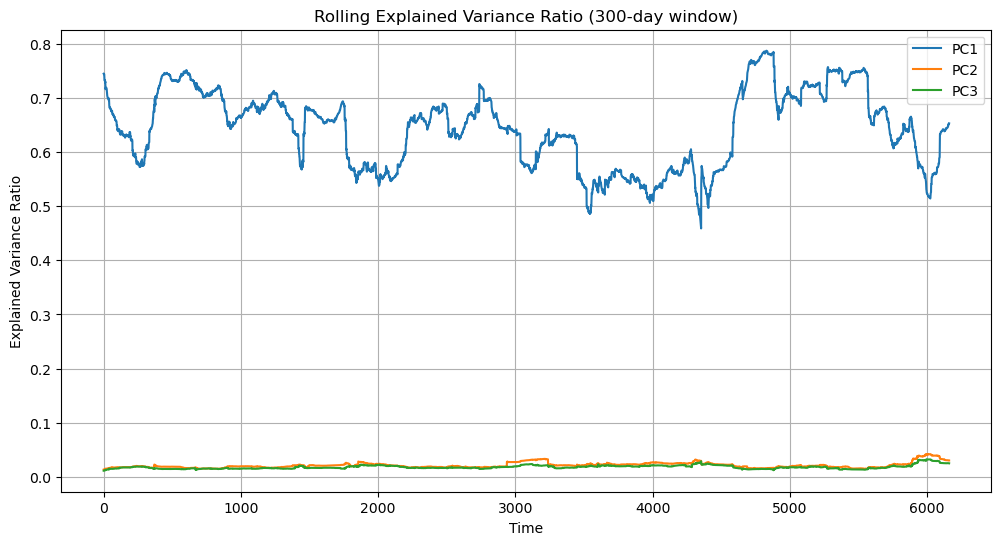

In [9]:
df = calc_resid_pca(daily_rets, n_components=3, window_size=50*6, plot_variance=True)

In [10]:
strat_time = 4

In [ ]:
n_comp_list = [1, 2]
len_n = len(n_comp_list)

net_sharpes = {x: {} for x in n_comp_list}
gross_sharpes = {x: {} for x in n_comp_list}
gross_cum_dict = {x: {} for x in n_comp_list}
net_cum_dict = {x: {} for x in n_comp_list}

betas = {x: {} for x in n_comp_list}
alphas = {x: {} for x in n_comp_list}

alpha_tstats = {x: {} for x in n_comp_list}
avg_ann = {x: {} for x in n_comp_list}
vol_ann = {x: {} for x in n_comp_list}
hit_rate = {x: {} for x in n_comp_list}
r_squared = {x: {} for x in n_comp_list}

to_mean = []

window_sizes = [x * 10 * 24 // strat_time for x in range(1, 12)]


for n_components in n_comp_list:

    for window_size in tqdm(window_sizes):

        resid_df = calc_resid_pca(daily_rets, n_components=n_components, window_size=window_size)

        resid_rank_thresh = transform_signal(-resid_df, how="rank", rank_thresh=.1)
        w = dollar_neutral_weights(resid_rank_thresh)

        w = partial_adjustment_weights(w, rho=0.8)

        combo = (w.shift() * daily_rets).sum(axis=1)

        to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(1)
        to_mean.append(to.mean())
        gross_ret = (w.shift()*daily_rets).sum(1)
        tcost_bps = 20 # (comissions + slip)
        net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)

        # Cumulative returns
        gross_cum_dict[n_components][window_size/(24//strat_time)] = (1 + gross_ret).cumprod() - 1
        net_cum_dict[n_components][window_size/(24//strat_time)] = (1 + net_ret).cumprod() - 1

        net_sharpes[n_components][window_size/(24//strat_time)] = net_ret.mean() / net_ret.std() * np.sqrt(252*(24/strat_time))
        gross_sharpes[n_components ][window_size/(24//strat_time)] = gross_ret.mean() / gross_ret.std() * np.sqrt(252*(24/strat_time))

        full_stats = stats.compute_full_stats(gross_ret, daily_rets["BTCUSDT"])
        betas[n_components][window_size/(24//strat_time)] = full_stats["beta"].iloc[0]
        alphas[n_components][window_size/(24//strat_time)] = full_stats["alpha_ann"].iloc[0]
        alpha_tstats[n_components][window_size/(24//strat_time)] = full_stats["alpha_tstat"].iloc[0]
        avg_ann[n_components][window_size/(24//strat_time)] = full_stats["avg_ann"].iloc[0]
        vol_ann[n_components][window_size/(24//strat_time)] = full_stats["vol_ann"].iloc[0]
        hit_rate[n_components][window_size/(24//strat_time)] = full_stats["hit_rate"].iloc[0]
        r_squared[n_components][window_size/(24//strat_time)] = full_stats["r_squared"].iloc[0]

 45%|████▌     | 5/11 [01:57<02:42, 27.16s/it]

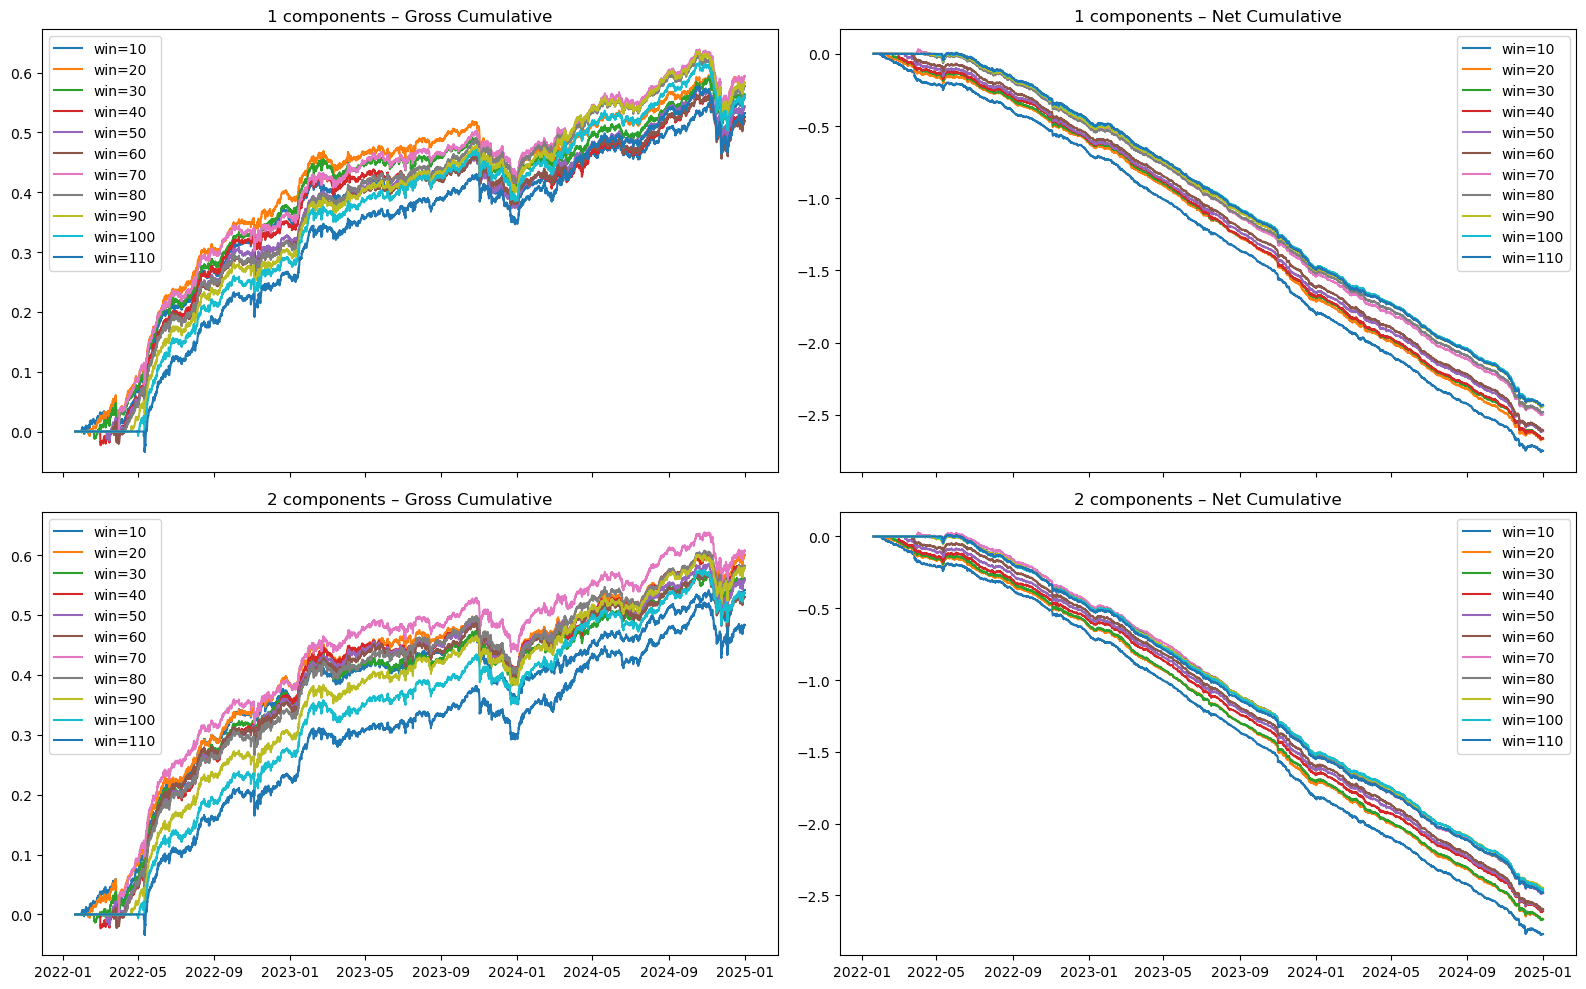

In [ ]:
fig, axes = plt.subplots(len_n, 2, figsize=(16, 10), sharex=True)

for row, n_components in enumerate(n_comp_list):

    for window_size in window_sizes:

        label = f"win={int(window_size/(24//strat_time))}"

        axes[row, 0].plot(gross_cum_dict[n_components][window_size/(24//strat_time)], label=label)

        axes[row, 1].plot(net_cum_dict[n_components][window_size/(24//strat_time)], label=label)
    
    axes[row, 0].set_title(f"{n_components} components – Gross Cumulative")
    axes[row, 1].set_title(f"{n_components} components – Net Cumulative")
    axes[row, 0].legend()
    axes[row, 1].legend()
plt.tight_layout()
plt.show()

<Axes: >

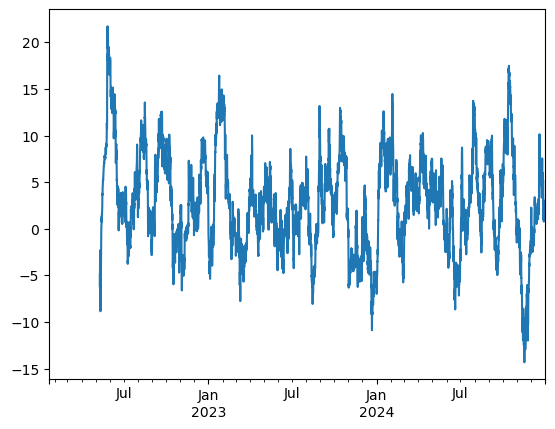

In [ ]:
(gross_ret.rolling(90).mean() / gross_ret.rolling(90).std() * np.sqrt(365*6)).plot()


<Axes: title={'center': 'Rolling 90-Day IC'}>

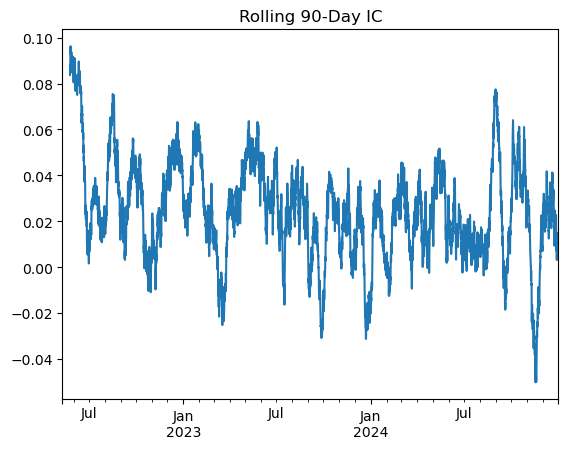

In [ ]:
common_idx = resid_rank_thresh.index.intersection(daily_rets.index)
signal = resid_rank_thresh.loc[common_idx]
daily_rets2 = daily_rets.loc[common_idx]

# 1-step ahead returns
fwd_rets = daily_rets2.shift(-1)

# Daily cross-sectional IC
daily_ic = (
    signal.corrwith(fwd_rets, axis=1)
)

# 90-day rolling IC
rolling_ic_90 = daily_ic.rolling(90).mean()

# Plot
rolling_ic_90.plot(title="Rolling 90-Day IC")

In [ ]:
yearly_ic = daily_ic.groupby(daily_ic.index.year).mean()
print(yearly_ic)

2022    0.037067
2023    0.021691
2024    0.020061
dtype: float64


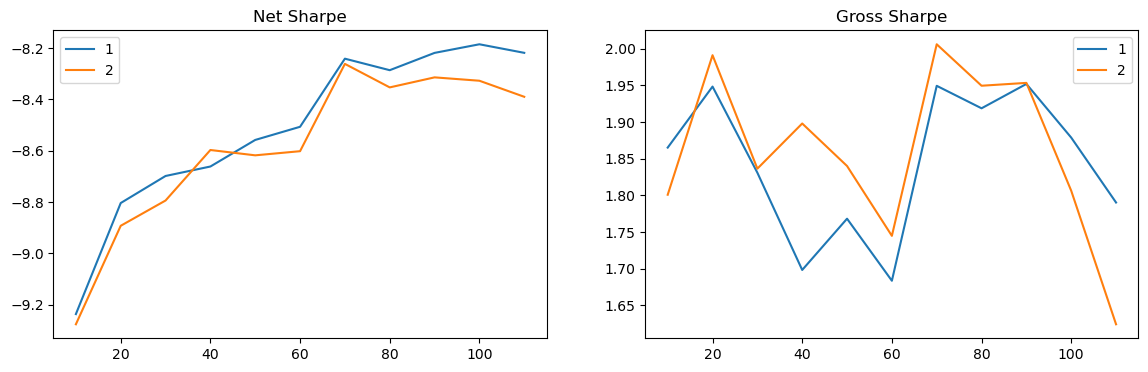

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

pd.DataFrame(net_sharpes).plot(ax=ax[0])
pd.DataFrame(gross_sharpes).plot(ax=ax[1])

ax[0].set_title("Net Sharpe")
ax[1].set_title("Gross Sharpe")

plt.show()

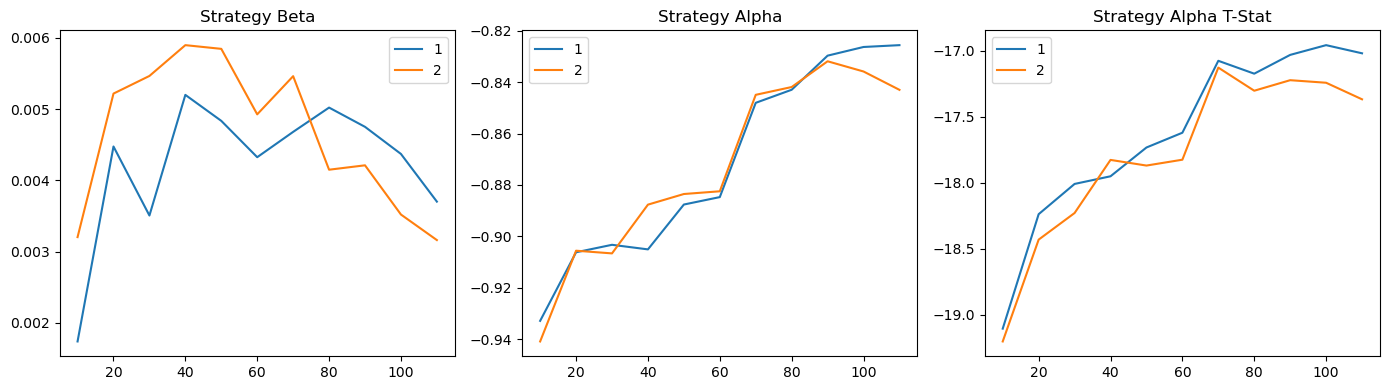

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

pd.DataFrame(betas).plot(ax=ax[0])
ax[0].set_title("Strategy Beta")

pd.DataFrame(alphas).plot(ax=ax[1])
ax[1].set_title("Strategy Alpha")

pd.DataFrame(alpha_tstats).plot(ax=ax[2])
ax[2].set_title("Strategy Alpha T-Stat")

plt.tight_layout()
plt.show()

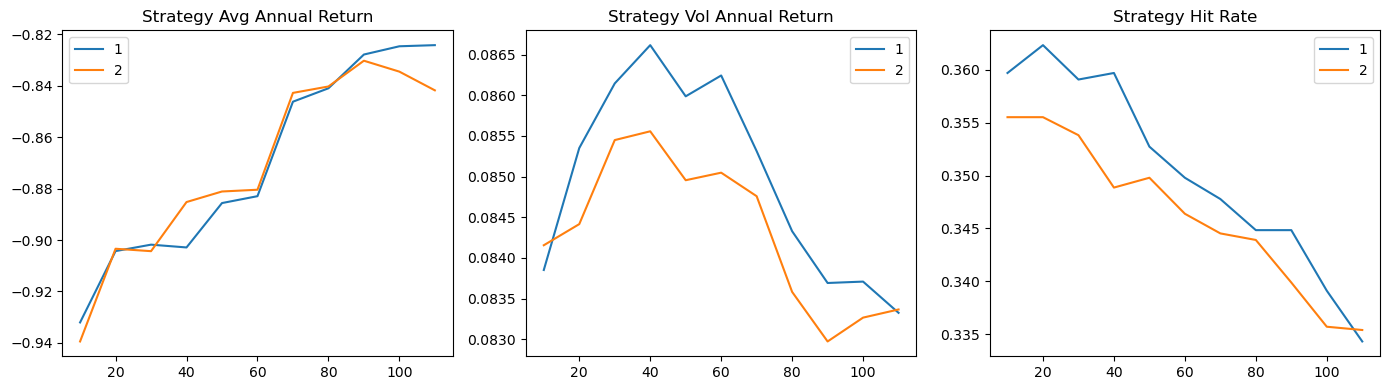

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

pd.DataFrame(avg_ann).plot(ax=ax[0])
ax[0].set_title("Strategy Avg Annual Return")

pd.DataFrame(vol_ann).plot(ax=ax[1])
ax[1].set_title("Strategy Vol Annual Return")

pd.DataFrame(hit_rate).plot(ax=ax[2])
ax[2].set_title("Strategy Hit Rate")


plt.tight_layout()
plt.show()